# Lab 6: Decision Tree Classifier  
### Using the Breast Cancer Wisconsin Dataset  

## Objective
In this lab, we use the same dataset from Lab 5 and implement a **Decision Tree Classifier**.  
Then, we compare its performance with the previously built **KNN model**.  
EDA is already completed in Lab 5, so it is not repeated here.

**Import Libraries**

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load Dataset**

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Feature Split**

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

**Train-Test Split**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

**Scaling (KNN Needs It, DT Doesn’t)**

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## KNN Model (Reference from Lab 5)

**Train KNN**

In [6]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)

## Decision Tree Classifier
Decision Tree can work directly on unscaled data because it is splitting-based rather than distance-based.

**Train Decision Tree**

In [7]:
dt = DecisionTreeClassifier(random_state=42) #entropy criterion
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

**Print Both Accuracies**

In [8]:
print("KNN Accuracy:", knn_acc)
print("Decision Tree Accuracy:", dt_acc)

KNN Accuracy: 0.958041958041958
Decision Tree Accuracy: 0.951048951048951


**Decision Tree Confusion Matrix & Report**

In [9]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94        54
           1       0.97      0.96      0.96        89

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

Decision Tree Confusion Matrix:
[[51  3]
 [ 4 85]]


**KNN Confusion Matrix & Report**

In [10]:
print("KNN Classification Report:")
print(classification_report(y_test, knn_pred))

print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143

KNN Confusion Matrix:
[[51  3]
 [ 3 86]]


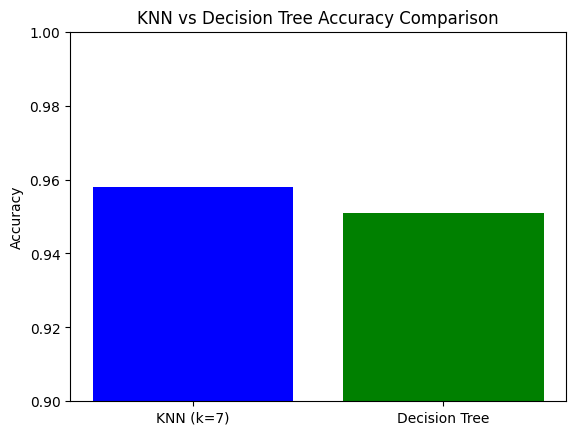

In [11]:
import matplotlib.pyplot as plt

models = ['KNN (k=7)', 'Decision Tree']
scores = [knn_acc, dt_acc]

plt.bar(models, scores, color=['blue', 'green'])
plt.ylabel("Accuracy")
plt.title("KNN vs Decision Tree Accuracy Comparison")
plt.ylim(0.90, 1.0)
plt.show()

## Observations

- Both KNN and Decision Tree models were trained using the same train–test split to ensure a fair comparison.
- KNN requires feature scaling because it uses distance-based calculations, whereas Decision Tree does not.
- After tuning, KNN achieved a slightly higher accuracy (0.9580) compared to the Decision Tree (0.9510).
- The Decision Tree trained faster but showed mild overfitting due to its tendency to memorize training splits.
- KNN performed well because the dataset consists of clean, well-separated numeric features, producing smoother decision boundaries.
- Decision Tree provides valuable interpretability, offering feature importance and clear rule-based structure.
- KNN handled minor variations effectively after scaling, while the Decision Tree’s performance was more sensitive to split patterns.
- Overall, both models performed strongly, but KNN demonstrated slightly better generalization on this dataset.